In [52]:
import os
from pathlib import Path
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random

In [53]:
cwd = Path.cwd()
print(f"Directorio actual: {cwd}")
path_dataset = cwd/"datasets"
path_dataset.mkdir(exist_ok=True)
print(f"Directorio del dataset: {path_dataset}")

Directorio actual: /content
Directorio del dataset: /content/datasets


# 1 - Cargamos dataset





In [54]:
# --- 1. Instalar gdown para descargar desde Google Drive ---
# El flag -q es para una instalación silenciosa.
print("📦 Instalando gdown...")
!pip install -q gdown

# --- 2. Descargar el archivo .ZIP desde Google Drive ---
# ¡IMPORTANTE! Pega aquí el enlace de tu archivo .zip compartido
drive_link = "https://drive.google.com/file/d/139GTZiVlxWrBUf_ww7iUVv0-wSjhDQ77/view?usp=sharing"

# Extraemos el ID de la URL
file_id = drive_link.split('/')[-2]

output_zip = 'thermal_images.zip'
print(f"⬇️  Descargando {output_zip} desde Google Drive...")
!gdown --id {file_id} -O {output_zip} --quiet
print("✅ Descarga completada.")

# --- 3. Descomprimir el archivo ---
output_folder = path_dataset
print(f"\n🌀 Descomprimiendo archivos en la carpeta '{output_folder}'...")
# Creamos el directorio si no existe
output_folder = Path.cwd().joinpath(output_folder)
output_folder.mkdir(exist_ok=True)

# Descomprimimos el zip en la carpeta de destino
!unzip -q -o {output_zip} -d {output_folder}
print("✅ Descompresión finalizada.")

# --- 4. Verificar los archivos ---
#folders = output_folder/"Thermal PV Panel Detection Dataset for UAV Inspection"
folders = output_folder/"dataset_pv_panels"
folders.mkdir(exist_ok=True)
print(f"\n📄 Contenido del directorio '{folders}':")
for folder in folders.iterdir():
    print(folder.name)


📦 Instalando gdown...
⬇️  Descargando thermal_images.zip desde Google Drive...
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
✅ Descarga completada.

🌀 Descomprimiendo archivos en la carpeta '/content/datasets'...
✅ Descompresión finalizada.

📄 Contenido del directorio '/content/datasets/dataset_pv_panels':
data.yaml
labels
images


In [55]:
other_test_images = "https://drive.google.com/file/d/1x-n9SAhbooUztWjMa0t3tdy6ZsS6_jg-/view?usp=sharing"
# Extraemos el ID de la URL

file_id1 = other_test_images.split('/')[-2]
# Descarga el archivo
!gdown --id $file_id1
!unzip -q 'tests_images.zip'

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1x-n9SAhbooUztWjMa0t3tdy6ZsS6_jg-
To: /content/tests_images.zip
100% 2.27M/2.27M [00:00<00:00, 43.7MB/s]
replace tests_images/paneles_drone.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace tests_images/paneles_en_techo.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace tests_images/Screenshot_1.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace tests_images/termo_panels.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace tests_images/Screenshot_3.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace tests_images/Screenshot_2.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace tests_images/paneles_techo2.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace tests_images/desktop.ini? [y]es, [n]o, [A]ll, [N]one, 

## 1.1 - Reestructuracion del dataset acorde a recomencaciones por Ultralytics.

Se reorganiza la informacion contenida en la carpeta "Thermal PV Panel Detection Dataset for UAV Inspection" de forma que siga la estructura recomenda por la documentacion de ultralytics

* La reorganización implica la creación de una estructura jerárquica con directorios de imágenes y etiquetas, cada uno con los subdirectorios "train", "val" y "test".
* Todos los archivos de imágenes y etiquetas correspondientes se trasladan de sus ubicaciones originales a sus respectivos directorios divididos dentro de la nueva estructura dataset_pv_panels.

* **Estructura de directorios:** La estructura de directorios recomendada por Ultralytics es la siguiente:
    ```
    dataset_name/
    ├── images/
    │   ├── train/
    │   ├── val/
    │   └── test/
    └── labels/
        ├── train/
        ├── val/
        └── test/
    ```

In [56]:
import shutil

# 1. Define base paths
source_base_path = path_dataset / "Thermal PV Panel Detection Dataset for UAV Inspection"
dest_base_path = path_dataset / "dataset_pv_panels"

# 2. Create necessary target directories
# Ensure the base destination path exists (already created by earlier step, but good to be explicit)
dest_base_path.mkdir(parents=True, exist_ok=True)

splits = ['train', 'val', 'test']

for split in splits:
    # Create images directories
    (dest_base_path / "images" / split).mkdir(parents=True, exist_ok=True)
    # Create labels directories
    (dest_base_path / "labels" / split).mkdir(parents=True, exist_ok=True)
    print(f"Created directories for {split}: {dest_base_path / 'images' / split} and {dest_base_path / 'labels' / split}")

# 3. Move files for each split
print("\nMoving dataset files...")
for split in splits:
    source_images_path = source_base_path / split / "images"
    dest_images_path = dest_base_path / "images" / split

    source_labels_path = source_base_path / split / "labels"
    dest_labels_path = dest_base_path / "labels" / split

    # Move images
    if source_images_path.exists():
        for img_file in source_images_path.iterdir():
            shutil.move(str(img_file), str(dest_images_path / img_file.name))
        print(f"Moved images from {source_images_path} to {dest_images_path}")
    else:
        print(f"Warning: Source images path not found for {split}: {source_images_path}")

    # Move labels
    if source_labels_path.exists():
        for label_file in source_labels_path.iterdir():
            shutil.move(str(label_file), str(dest_labels_path / label_file.name))
        print(f"Moved labels from {source_labels_path} to {dest_labels_path}")
    else:
        print(f"Warning: Source labels path not found for {split}: {source_labels_path}")

print("\nDataset reorganization complete.")

Created directories for train: /content/datasets/dataset_pv_panels/images/train and /content/datasets/dataset_pv_panels/labels/train
Created directories for val: /content/datasets/dataset_pv_panels/images/val and /content/datasets/dataset_pv_panels/labels/val
Created directories for test: /content/datasets/dataset_pv_panels/images/test and /content/datasets/dataset_pv_panels/labels/test

Moving dataset files...
Moved images from /content/datasets/Thermal PV Panel Detection Dataset for UAV Inspection/train/images to /content/datasets/dataset_pv_panels/images/train
Moved labels from /content/datasets/Thermal PV Panel Detection Dataset for UAV Inspection/train/labels to /content/datasets/dataset_pv_panels/labels/train
Moved images from /content/datasets/Thermal PV Panel Detection Dataset for UAV Inspection/val/images to /content/datasets/dataset_pv_panels/images/val
Moved labels from /content/datasets/Thermal PV Panel Detection Dataset for UAV Inspection/val/labels to /content/datasets/da

In [57]:
path_pv_dataset = path_dataset/"dataset_pv_panels"

if path_pv_dataset.exists():
  for i in path_pv_dataset.iterdir():
    print(i.name)
else:
  print("No existe la carpeta")

data.yaml
labels
images


## 1.2 Visualización de imagenes y sus bounding boxes de manera aleatoria

Tiene como objetivo presentar de manera aleatoria las diferentes imagenes y los bounding boxes que localizan los paneles solares, esto ademas ayuda a identificar si se hay error en la coincidencia de imagenes y labels.

In [58]:
def display_random_images_with_annotations(root_dataset_path: Path, split_name: str, num_images: int = 6):
    """
    Displays a specified number of random images with their bounding boxes drawn
    from a specific split of the reorganized dataset.

    Args:
        root_dataset_path (Path): The root path to the reorganized dataset (e.g., path_dataset / "dataset_pv_panels").
        split_name (str): The name of the split ('train', 'val', or 'test').
        num_images (int): The number of random images to display.
    """
    images_dir = root_dataset_path / "images" / split_name
    labels_dir = root_dataset_path / "labels" / split_name

    if not images_dir.exists():
        print(f"Error: Images directory not found: {images_dir}")
        return
    if not labels_dir.exists():
        print(f"Error: Labels directory not found: {labels_dir}")
        return

    images_paths = list(images_dir.iterdir())

    # Asegurarse de que hay suficientes imágenes para mostrar
    num_images_to_show = min(num_images, len(images_paths))

    if num_images_to_show == 0:
        print(f"No images found in {images_dir}")
        return

    # Seleccionar índices aleatorios
    selected_indices = random.sample(range(len(images_paths)), num_images_to_show)

    # Configurar el subplot
    # Calcular el número de filas necesario para mostrar todas las imágenes
    nrows = (num_images_to_show + 2) // 3 # Divide por 3 y redondea hacia arriba
    fig, axes = plt.subplots(nrows=nrows, ncols=3, figsize=(15, 5 * nrows))
    axes = axes.flatten() # Aplanar el array de ejes para facilitar la iteración

    print(f"\nMostrando {num_images_to_show} imágenes de la división '{split_name}' con sus anotaciones:")

    for i, idx in enumerate(selected_indices):
        image_path = images_paths[idx]
        label_path = labels_dir / f"{image_path.stem}.txt" # Construir la ruta del label

        img = cv2.imread(str(image_path))
        # Check if the image was loaded successfully
        if img is None:
            print(f"Warning: Could not load image {image_path}")
            axes[i].axis('off') # Hide the axis if image could not be loaded
            continue

        h, w, _ = img.shape

        if not label_path.exists():
            print(f"Label file not found for {image_path.name}")
            # Mostrar la imagen sin anotaciones si el label no existe
            axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            axes[i].set_title(f"Image {i+1} (No Label)")
            axes[i].axis('off')
            continue

        # Draw bounding boxes (assuming YOLO format: class_id x_center y_center width height)
        with open(label_path, 'r') as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) < 5:
                    print(f"Warning: Invalid label format in {label_path} for line: {line.strip()}")
                    continue
                # The first part is class_id, rest are normalized bbox coords
                class_id = int(parts[0]) # Class ID is usually an integer
                x_center, y_center, bbox_width, bbox_height = map(float, parts[1:])

                # Convert normalized YOLO coordinates to pixel coordinates
                x_center_px = int(x_center * w)
                y_center_px = int(y_center * h)
                bbox_width_px = int(bbox_width * w)
                bbox_height_px = int(bbox_height * h)

                x1 = int(x_center_px - bbox_width_px / 2)
                y1 = int(y_center_px - bbox_height_px / 2)
                x2 = int(x_center_px + bbox_width_px / 2)
                y2 = int(y_center_px + bbox_height_px / 2)

                # Draw rectangle
                color = (0, 255, 0) # Green color for bounding box in BGR
                thickness = 2
                cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
                # Optionally add text for class_id
                # cv2.putText(img, str(class_id), (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, thickness)

        # Convert image from BGR (OpenCV default) to RGB (Matplotlib default) for display
        axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[i].set_title(f"Image {i+1}")
        axes[i].axis('off')

    # Hide any unused subplots
    for j in range(num_images_to_show, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


Mostrando 6 imágenes de la división 'train' con sus anotaciones:


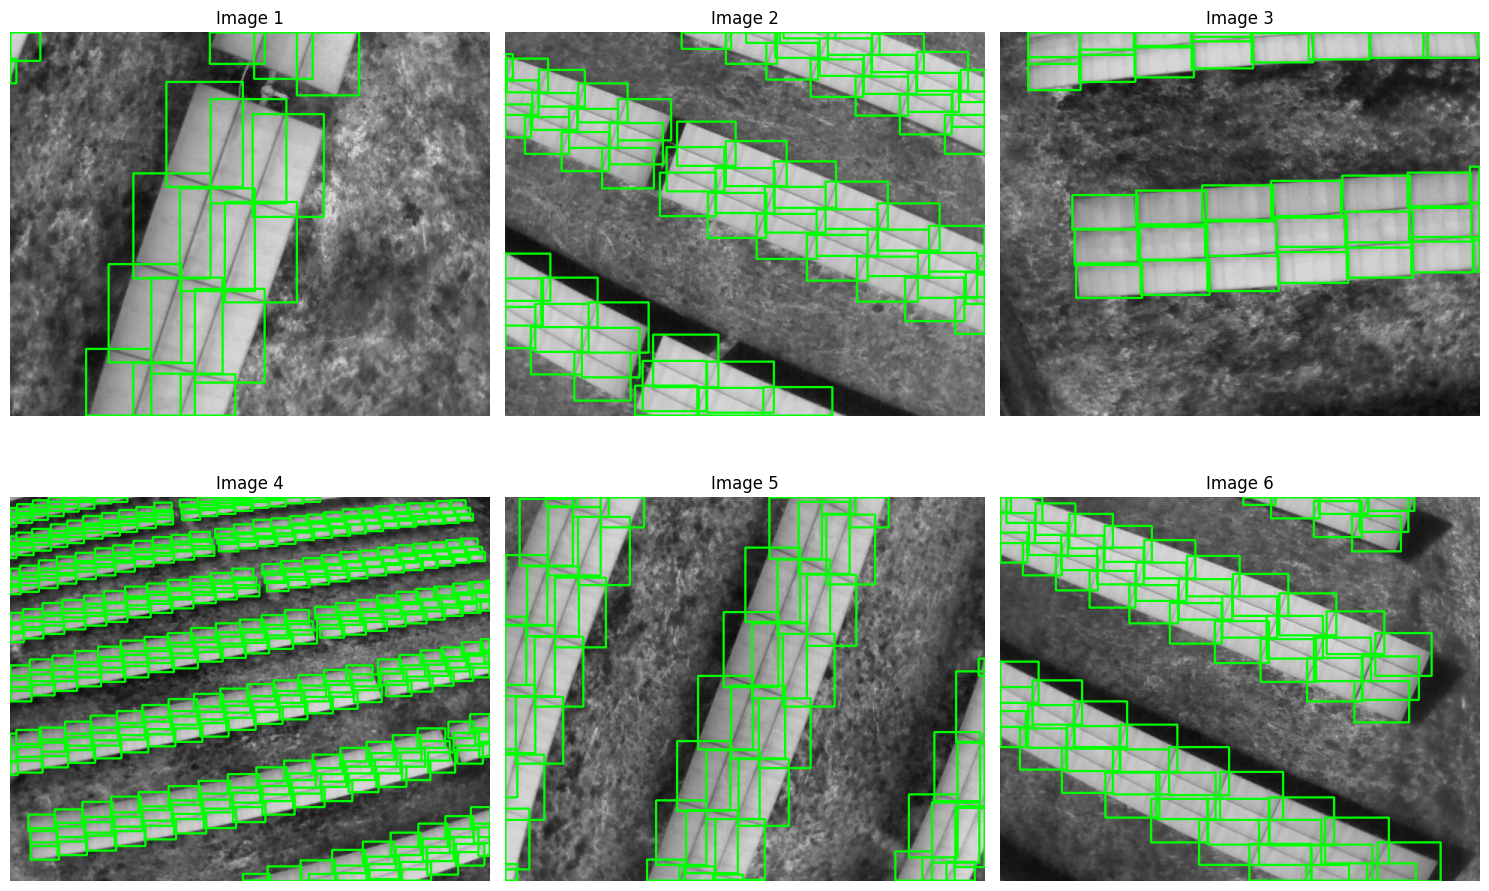

In [59]:
# Ejemplo de uso de la función adaptada para el split 'train'
display_random_images_with_annotations(path_pv_dataset, "train", num_images=6)

In [60]:
#Dimensiones de las imagenes
images_train_path = path_pv_dataset/"images"/"train"
images = list(images_train_path.iterdir())
img = cv2.imread(str(images[0]))
img.shape

(512, 640, 3)

Abrimos de manera aleatoria un archivo contenino en labels, para ver como se presnetan.

Este archivo contiene una lista de paneles solares detectados en una imagen, donde cada línea representa un bounding box en formato YOLO: [clase_id] [x_centro_normalizado] [y_centro_normalizado] [ancho_normalizado] [alto_normalizado].

In [61]:
# Ensure path_pv_dataset is defined (it should be from previous cells)
if 'path_pv_dataset' not in locals():
    print("Error: 'path_pv_dataset' no está definida. Asegúrate de que las celdas anteriores se han ejecutado.")
else:
    labels_train_path = path_pv_dataset / "labels" / "train"

    if not labels_train_path.exists():
        print(f"Error: El directorio de etiquetas de prueba no se encontró: {labels_train_path}")
    else:
        all_label_paths = list(labels_train_path.iterdir())

        if not all_label_paths:
            print(f"No se encontraron archivos de etiquetas en {labels_train_path}")
        else:
            # Select a random label file
            random_label_path = random.choice(all_label_paths)
            print(f"Contenido del archivo de etiqueta aleatorio '{random_label_path.name}':\n")

            # Read and print the content
            with open(random_label_path, 'r') as f:
                content = f.read()
                print(content)

Contenido del archivo de etiqueta aleatorio 'DJI_20230213164756_0114_T_JPG.rf.6bae66481496bd38e3ca869d747647dd.txt':

0 0.52509375 0.59388671875 0.11360937500000005 0.1842187500000001
0 0.148640625 0.13375 0.10884374999999998 0.17474609375
0 0.5704687500000001 0.436484375 0.11159374999999994 0.18712890625
0 0.1608125 0.31390625 0.10921875 0.18025390625000004
0 0.690515625 0.2465625 0.10571874999999994 0.18312500000000004
0 0.6271875 0.4659375 0.10800000000000001 0.18431640625
0 0.21014062500000003 0.1567578125 0.10921874999999999 0.17875000000000002
0 0.10323437499999999 0.2848828125 0.10789062500000002 0.18074218750000004
0 0.585 0.62490234375 0.10879687499999999 0.18058593750000007
0 0.751328125 0.28146484375 0.09662500000000004 0.17806640625000003
0 0.222390625 0.3405078125 0.108203125 0.17976562500000004
0 0.059 0.43841796875000005 0.09884375000000001 0.17726562500000004
0 0.645671875 0.64796875 0.10470312499999998 0.17427734375000004
0 0.475265625 0.7563671875 0.10932812500000004 

# 2 - Afinacion del modelos YOLO nano

## 2.1- Creación del archivo de configuración

Archivo de configuración que le indica al modelo dónde se encontran los datos de entrenamiento, validación y prueba, y qué clases de objetos debe detectar.

In [62]:
path_pv_dataset

PosixPath('/content/datasets/dataset_pv_panels')

In [63]:
import yaml

data = {
    'path': '../datasets/dataset_pv_panels',
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'names': {
        0: 'pv'
    }
}

with open('/content/datasets/dataset_pv_panels/data.yaml', 'w') as file:
    yaml.dump(data, file,
              default_flow_style=False,
              sort_keys=False)

## 2.2 - Afinación de YOLO8 (detección) con el dataset

Para poder acceder al modelo pre-entrenado debemos comenzar instalando la librería "ultralytics":

Luego debemos llevar a cabo dos pasos para afinar el modelo:

1. Importar el modelo pre-entrenado
2. Usar el método "train" para realizar la afinación

Por defecto en cada iteración de entrenamiento se almacenarán los pesos del modelo afinado en la carpeta "runs".

In [64]:
!pip install ultralytics

y



In [65]:
from ultralytics import YOLO
# 1. Cargar el modelo (nano, el más pequeño)
model_v8 = YOLO("yolov8n.pt")

In [66]:
# Afinar el modelo
results_v8 = model_v8.train(data="/content/datasets/dataset_pv_panels/data.yaml",
                      epochs=10, # Número de iteraciones
                      imgsz=640, # Tamaño de las imágenes (máxima dimensión)
                      plots=True, # Guardar gráficos de entrenamiento
                      )

Ultralytics 8.3.234 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/dataset_pv_panels/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0

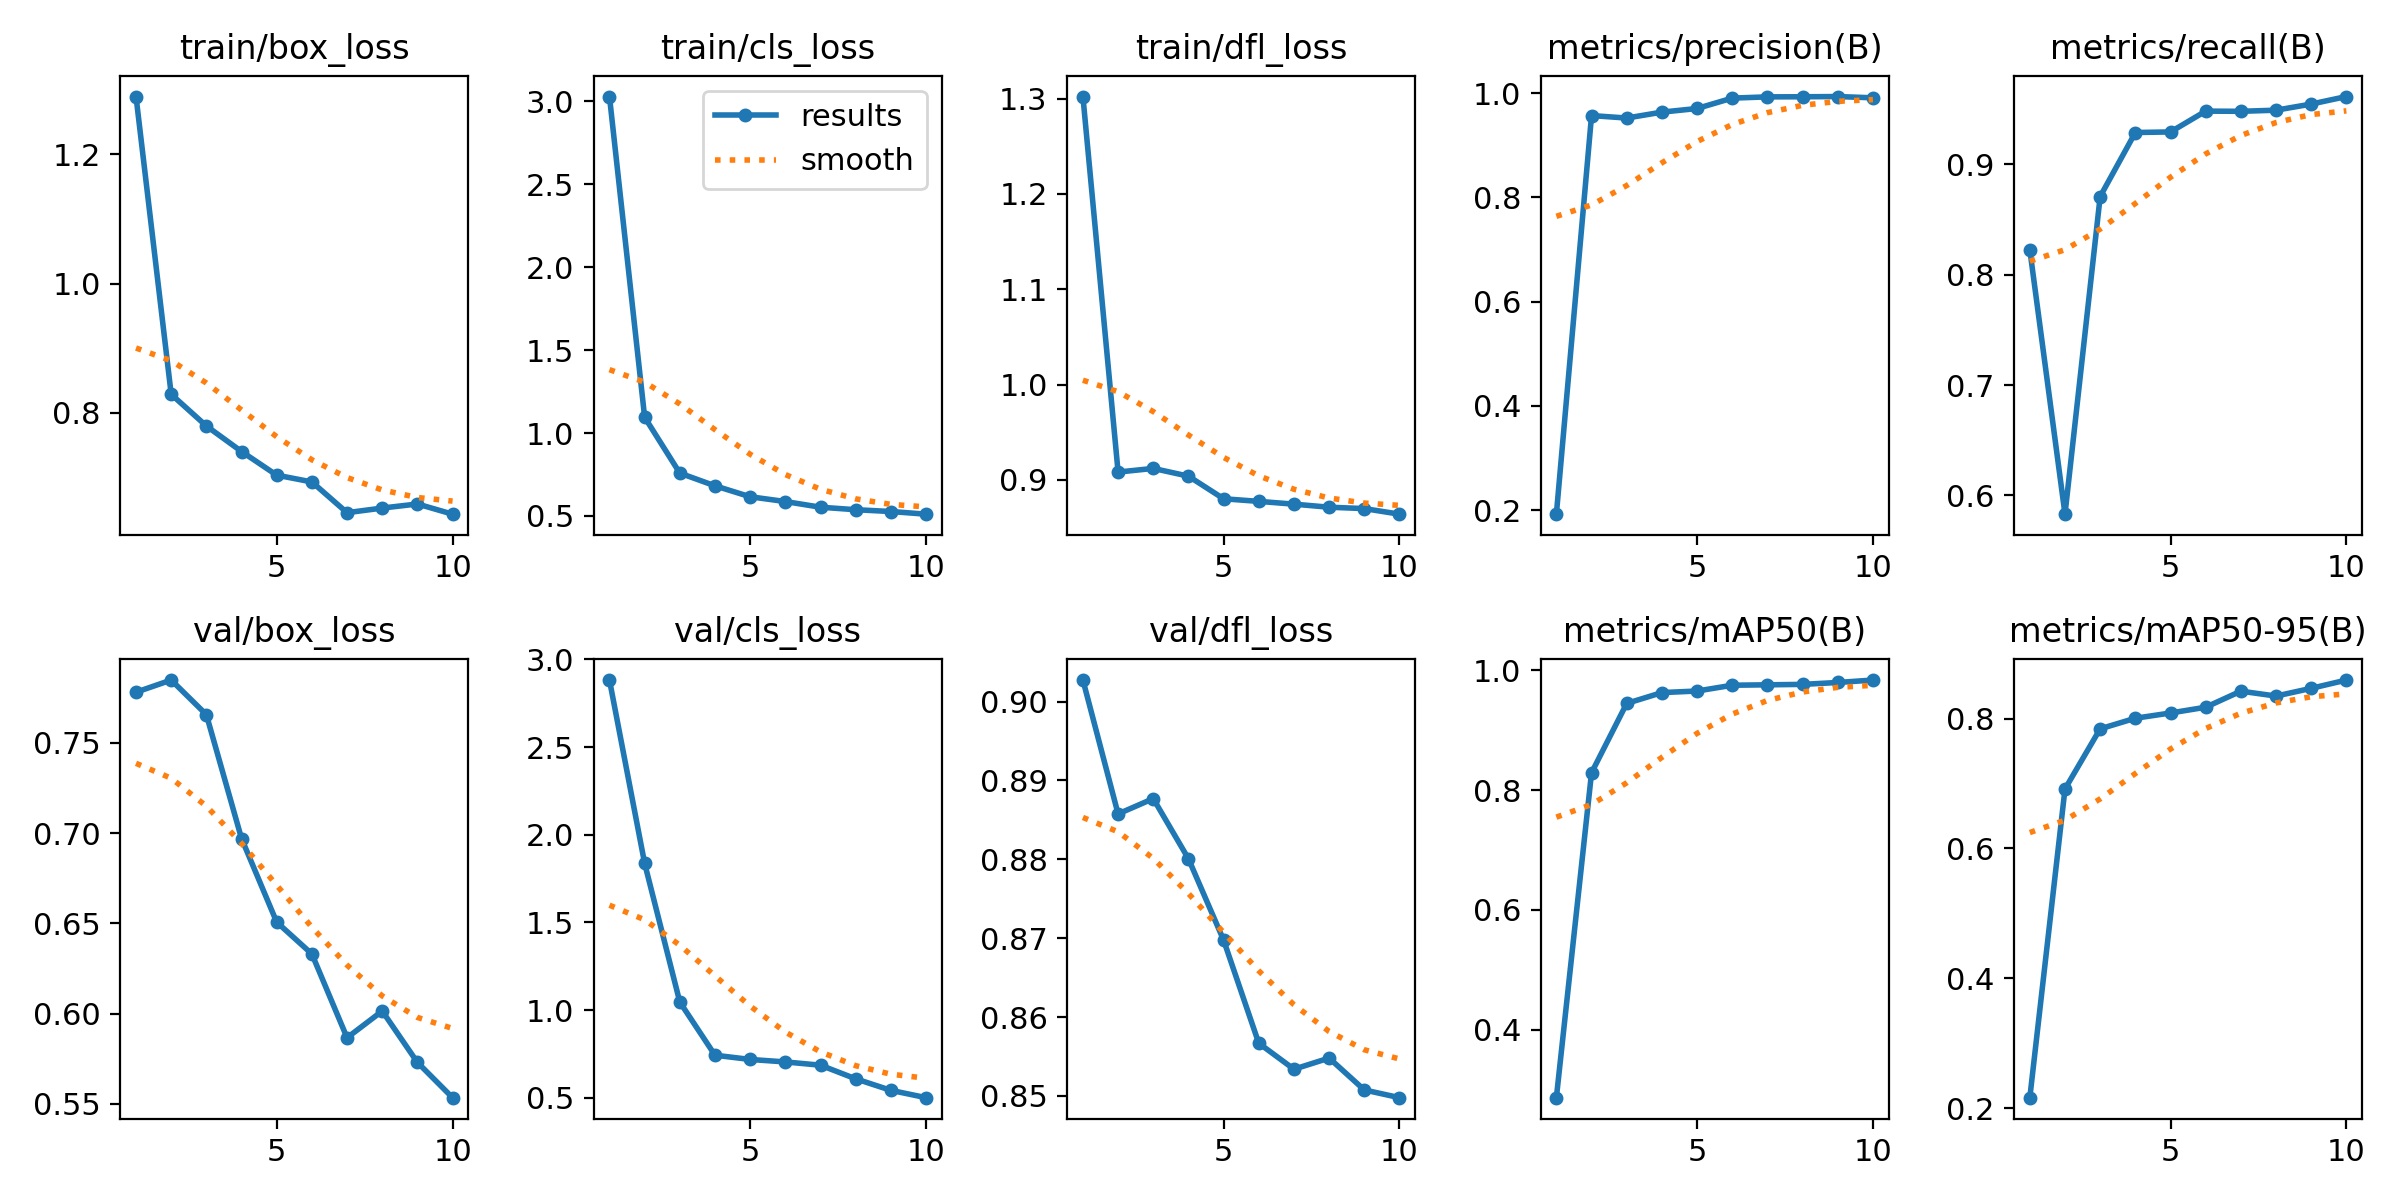

In [67]:
from IPython.display import Image as IPyImage

IPyImage(filename='/content/runs/detect/train/results.png', width=800)

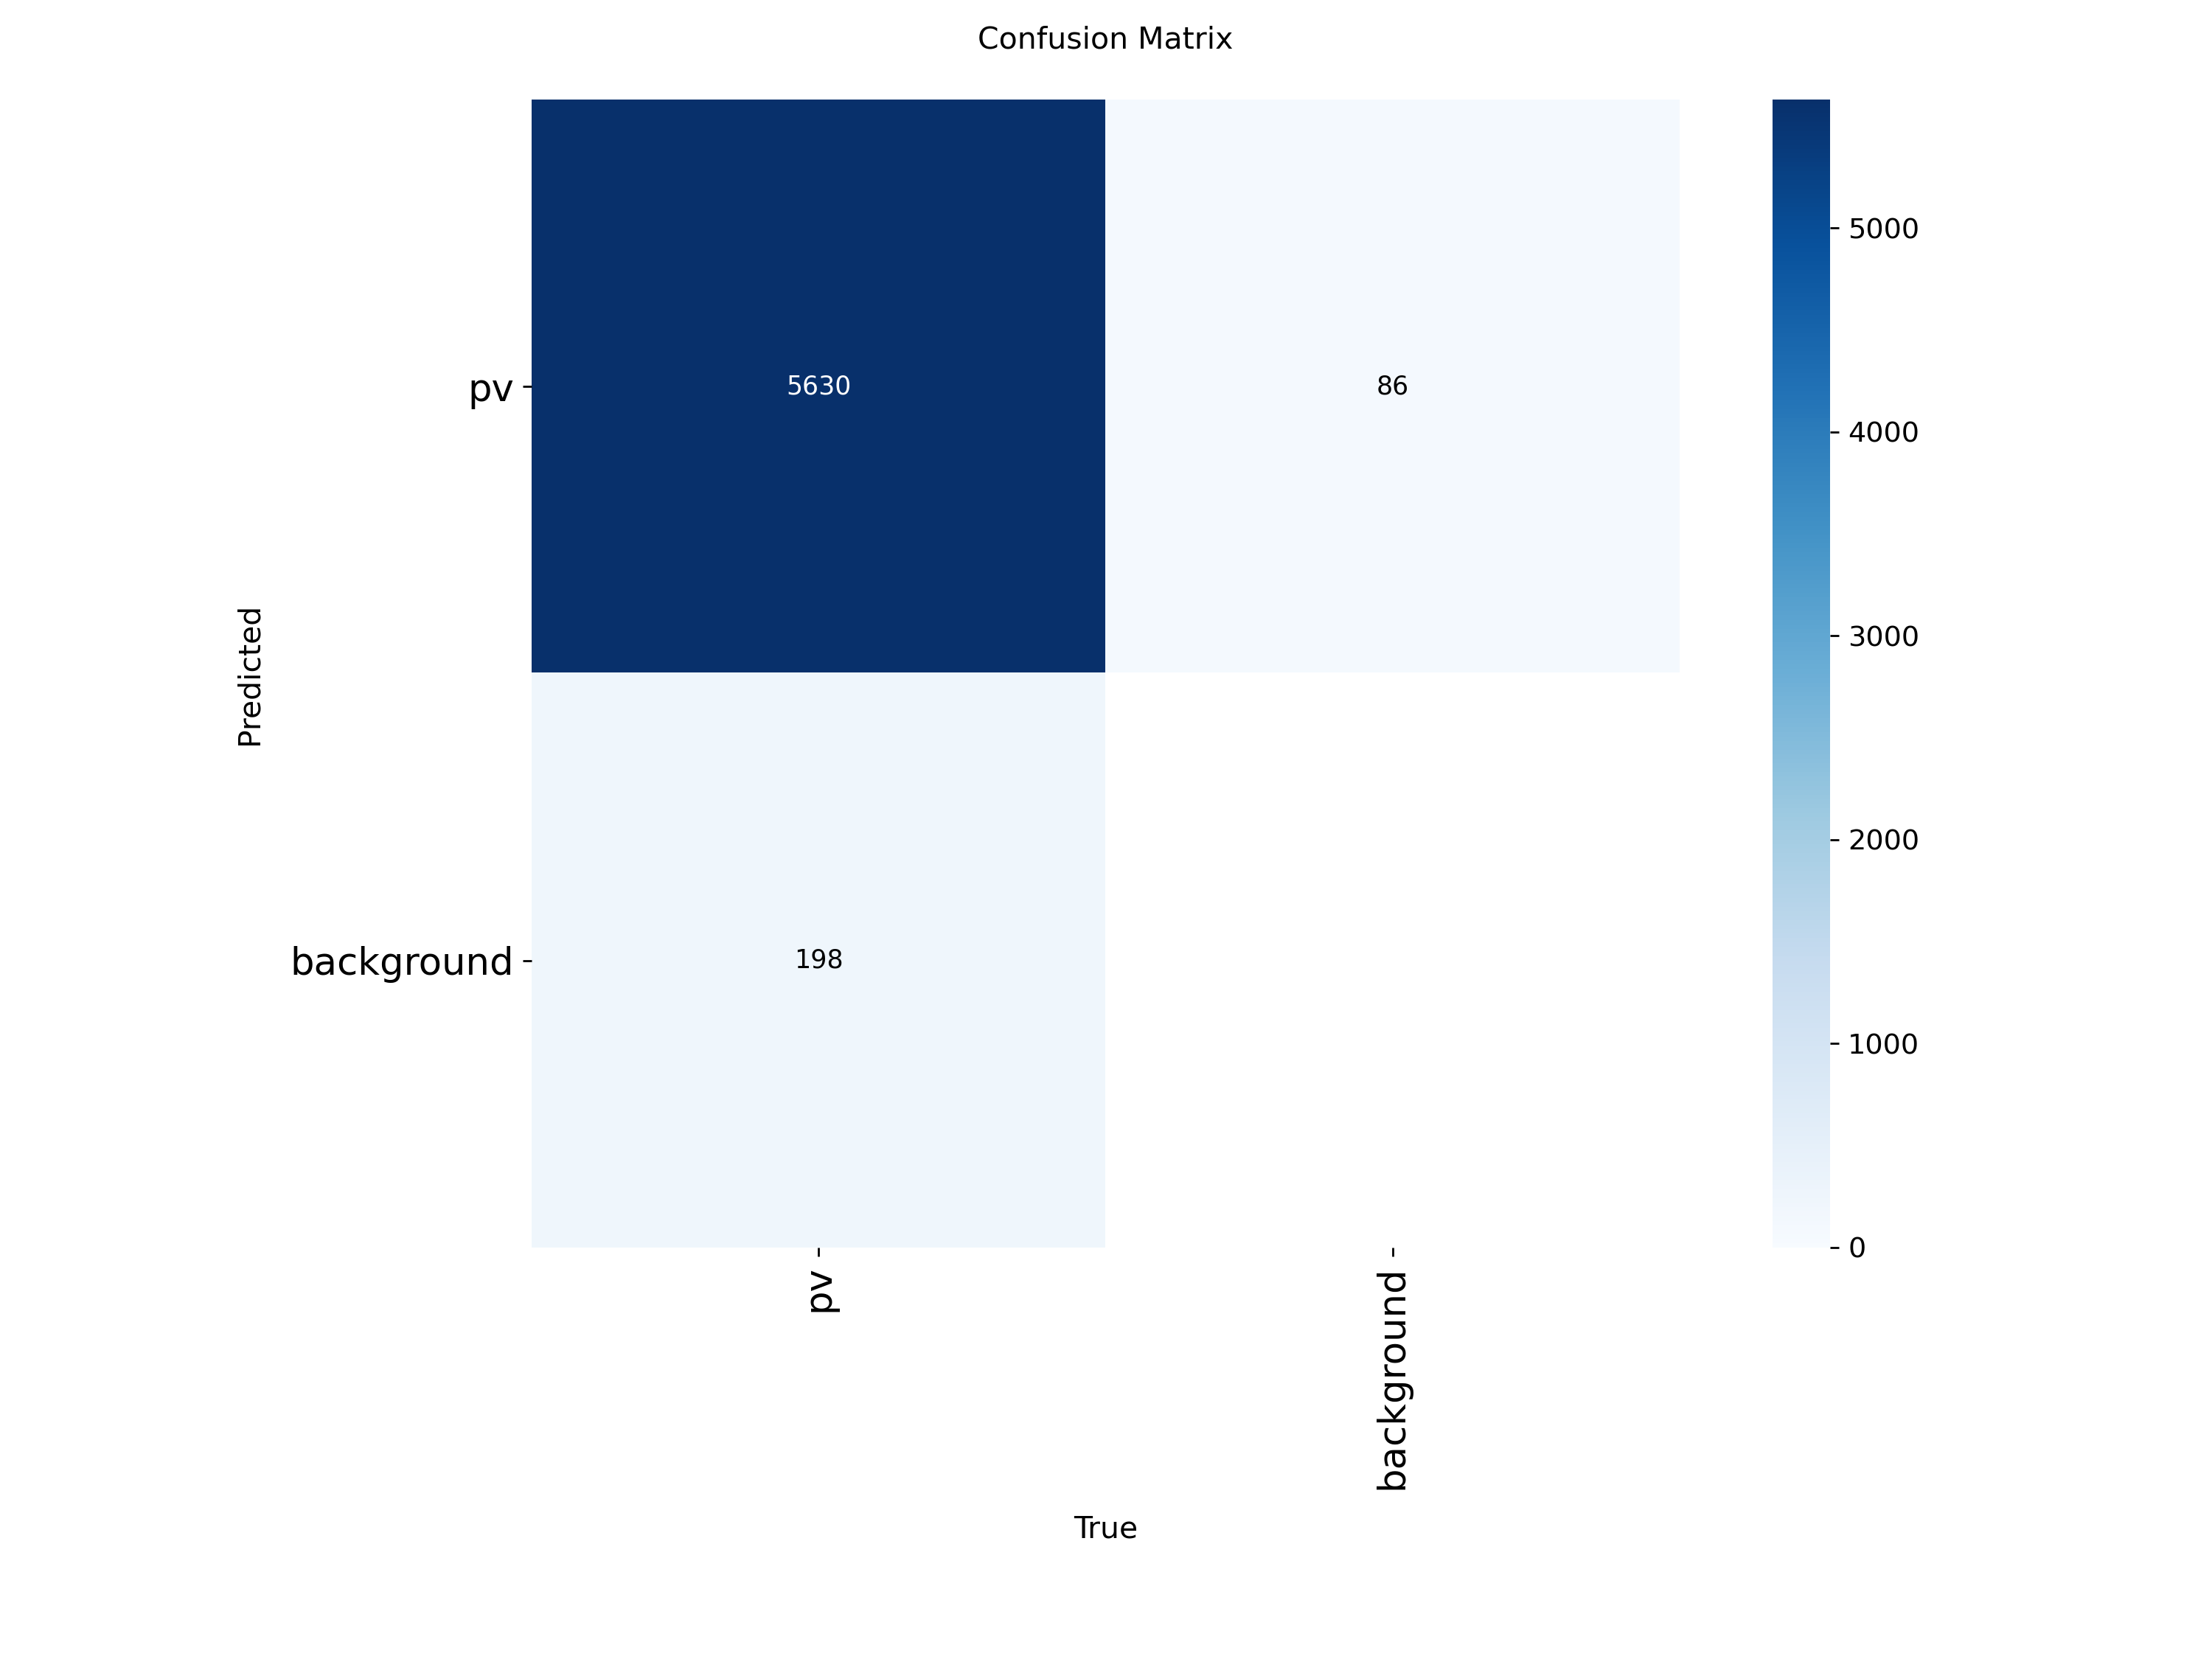

In [68]:
IPyImage(filename='/content/runs/detect/train/confusion_matrix.png', width=600)

## 2.3 - Generación de predicciones con el modelo afinado yolo v8 nano
Usamos el set de prueba (disponible en la carpeta ../datasets/dataset_pv_panels/images/test) para generar predicciones sobre nuevos datos usando el modelo afinado.



In [69]:
# Mostrar predicciones
model_v8 = YOLO('/content/runs/detect/train/weights/best.pt')
preds = model_v8('/content/datasets/dataset_pv_panels/images/test')



image 1/35 /content/datasets/dataset_pv_panels/images/test/DJI_20230213153545_0028_T_JPG.rf.2e6811dc7efbb66d491177c8ef91ab9e.jpg: 512x640 13 pvs, 269.7ms
image 2/35 /content/datasets/dataset_pv_panels/images/test/DJI_20230213153619_0029_T_JPG.rf.6655c7256ae6698edfdbe61bff6546e9.jpg: 512x640 64 pvs, 222.0ms
image 3/35 /content/datasets/dataset_pv_panels/images/test/DJI_20230213153842_0062_T_JPG.rf.541b8e07ff96d82b22f1bb8449dc71b4.jpg: 512x640 76 pvs, 229.6ms
image 4/35 /content/datasets/dataset_pv_panels/images/test/DJI_20230213154049_0091_T_JPG.rf.8fd858ff6a748dd9d1773c068a5e3ec4.jpg: 512x640 86 pvs, 203.9ms
image 5/35 /content/datasets/dataset_pv_panels/images/test/DJI_20230213154113_0095_T_JPG.rf.0912d83cce816b165043342ba1fba119.jpg: 512x640 107 pvs, 224.3ms
image 6/35 /content/datasets/dataset_pv_panels/images/test/DJI_20230213154227_0113_T_JPG.rf.70c2736befc0486960d77cfb7346522f.jpg: 512x640 85 pvs, 210.8ms
image 7/35 /content/datasets/dataset_pv_panels/images/test/DJI_20230213154

In [70]:
metrics = model_v8.val(split='test')

print("\nMétricas de rendimiento en el conjunto de prueba:")
print(f"  mAP50: {metrics.results_dict['metrics/mAP50(B)']:.3f}")
print(f"  mAP50-95: {metrics.results_dict['metrics/mAP50-95(B)']:.3f}")
print(f"  Precision: {metrics.results_dict['metrics/precision(B)']:.3f}")
print(f"  Recall: {metrics.results_dict['metrics/recall(B)']:.3f}")

Ultralytics 8.3.234 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 644.6±324.8 MB/s, size: 41.8 KB)
val: Scanning /content/datasets/dataset_pv_panels/labels/test.cache... 35 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 35/35 45.6Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 3.8s/it 11.5s
                   all         35       2363      0.975      0.959      0.991      0.852
Speed: 2.3ms preprocess, 286.0ms inference, 0.0ms loss, 17.6ms postprocess per image
Results saved to /content/runs/detect/val4

Métricas de rendimiento en el conjunto de prueba:
  mAP50: 0.991
  mAP50-95: 0.852
  Precision: 0.975
  Recall: 0.959


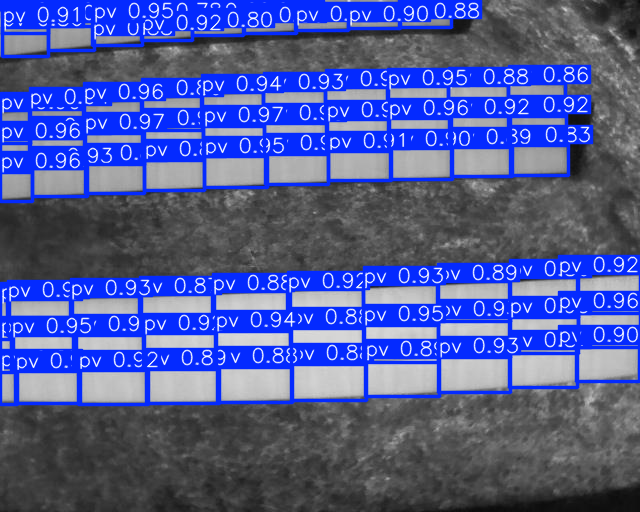

In [71]:
preds[2].show()

Muestra a una imagen aleatoria, la predicción realizada con un recuadro verde se muestra la marcada o idea y con un recuadro rojo la predicción

Selected random test image: DJI_20230213164146_0073_T_JPG.rf.06a0a8b8df6af8306212653642f20492.jpg
Image loaded with shape: (512, 640, 3)
Found 186 ground truth annotations.

image 1/1 /content/datasets/dataset_pv_panels/images/test/DJI_20230213164146_0073_T_JPG.rf.06a0a8b8df6af8306212653642f20492.jpg: 512x640 213 pvs, 285.5ms
Speed: 3.2ms preprocess, 285.5ms inference, 3.0ms postprocess per image at shape (1, 3, 512, 640)
Model predictions generated.


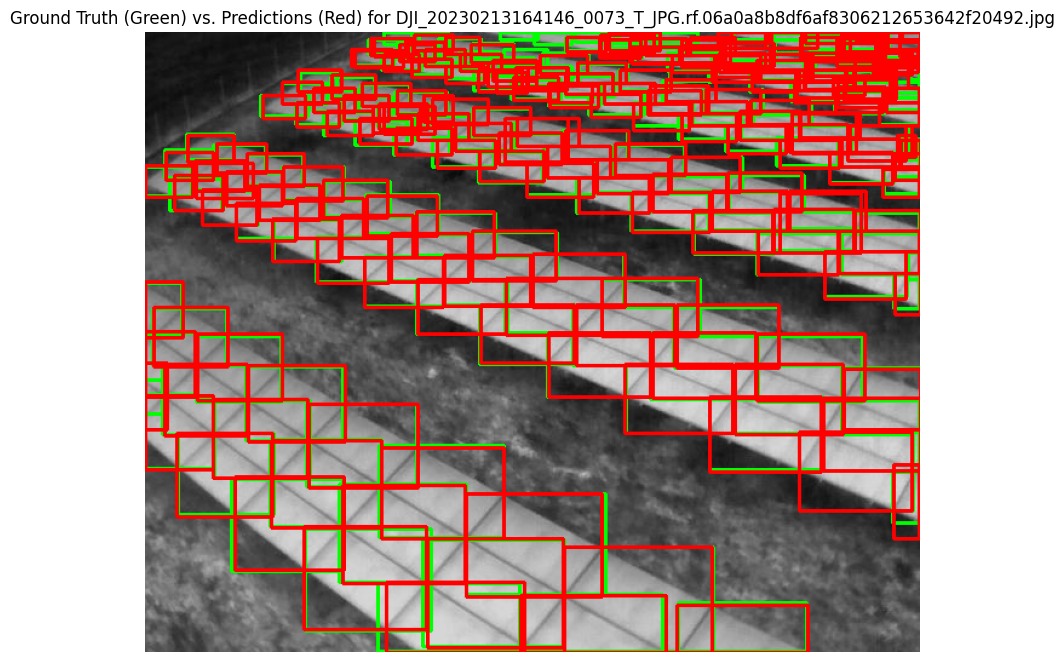

Ground truth vs. predicted bounding box visualization complete for the selected image.


In [72]:
# 1. Define base paths for the dataset's test images and labels
images_test_path = path_pv_dataset / "images" / "test"
labels_test_path = path_pv_dataset / "labels" / "test"

# 2. Get a list of all image file paths within the test directory.
all_test_image_paths = list(images_test_path.iterdir())

# Ensure there are images to process
if not all_test_image_paths:
    print(f"No images found in {images_test_path}")
else:
    # 3. Randomly select one image path from this list for visualization
    selected_image_path = random.choice(all_test_image_paths)
    print(f"Selected random test image: {selected_image_path.name}")

    # 4. Load the selected image using cv2.imread()
    img = cv2.imread(str(selected_image_path))
    if img is None:
        print(f"Error: Could not load image {selected_image_path}")
    else:
        h, w, _ = img.shape
        print(f"Image loaded with shape: {img.shape}")

        # 5. Prepare to load ground truth annotations:
        # Construct the full path to the corresponding YOLO label .txt file
        label_filename = selected_image_path.stem + ".txt"
        ground_truth_label_path = labels_test_path / label_filename

        ground_truth_boxes = [] # Initialize an empty list to store ground truth bounding boxes.

        if ground_truth_label_path.exists():
            with open(ground_truth_label_path, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if len(parts) == 5:
                        class_id = int(parts[0])
                        x_center_norm, y_center_norm, width_norm, height_norm = map(float, parts[1:])

                        # Convert normalized YOLO coordinates to absolute pixel coordinates (x1, y1, x2, y2)
                        x_center_px = int(x_center_norm * w)
                        y_center_px = int(y_center_norm * h)
                        box_width_px = int(width_norm * w)
                        box_height_px = int(height_norm * h)

                        x1 = int(x_center_px - box_width_px / 2)
                        y1 = int(y_center_px - box_height_px / 2)
                        x2 = int(x_center_px + box_width_px / 2)
                        y2 = int(y_center_px + box_height_px / 2)

                        ground_truth_boxes.append((x1, y1, x2, y2))
            print(f"Found {len(ground_truth_boxes)} ground truth annotations.")
        else:
            print(f"No ground truth label file found for {selected_image_path.name} at {ground_truth_label_path}")

        # 6. Create a copy of the loaded image to draw on.
        display_img = img.copy()

        # 7. On this copied image, draw each ground truth bounding box as a green rectangle using cv2.rectangle().
        for (x1, y1, x2, y2) in ground_truth_boxes:
            cv2.rectangle(display_img, (x1, y1), (x2, y2), (0, 255, 0), 2) # Green color, thickness 2

        # 8. Run the already loaded model on the selected image path to get predictions.
        yolo_results = model_v8(str(selected_image_path))
        print("Model predictions generated.")

        # 9. Iterate through the model's prediction results for the image:
        for result in yolo_results:
            for box in result.boxes:
                # Extract bounding box coordinates (x1, y1, x2, y2)
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                confidence = box.conf[0] # Optional: confidence score

                # Draw each predicted bounding box as a red rectangle using cv2.rectangle() on the same copied image.
                cv2.rectangle(display_img, (x1, y1), (x2, y2), (0, 0, 255), 2) # Red color, thickness 2

        # 10. Convert the final image (with both green and red bounding boxes) from BGR to RGB format
        display_img_rgb = cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB)

        # 11. Display the image using plt.imshow(), add an appropriate title, and use plt.axis('off') and plt.show().
        plt.figure(figsize=(10, 10))
        plt.imshow(display_img_rgb)
        plt.title(f'Ground Truth (Green) vs. Predictions (Red) for {selected_image_path.name}')
        plt.axis('off')
        plt.show()

print("Ground truth vs. predicted bounding box visualization complete for the selected image.")

## 2.4 Mapas de filtros según la capa

In [73]:
images_stages = model_v8.predict(selected_image_path,visualize=True)


Saving /content/runs/detect/predict4/DJI_20230213164146_0073_T_JPG.rf.06a0a8b8df6af8306212653642f20492/stage0_Conv_features.png... (16/16)
Saving /content/runs/detect/predict4/DJI_20230213164146_0073_T_JPG.rf.06a0a8b8df6af8306212653642f20492/stage1_Conv_features.png... (32/32)
Saving /content/runs/detect/predict4/DJI_20230213164146_0073_T_JPG.rf.06a0a8b8df6af8306212653642f20492/stage2_C2f_features.png... (32/32)
Saving /content/runs/detect/predict4/DJI_20230213164146_0073_T_JPG.rf.06a0a8b8df6af8306212653642f20492/stage3_Conv_features.png... (32/64)
Saving /content/runs/detect/predict4/DJI_20230213164146_0073_T_JPG.rf.06a0a8b8df6af8306212653642f20492/stage4_C2f_features.png... (32/64)
Saving /content/runs/detect/predict4/DJI_20230213164146_0073_T_JPG.rf.06a0a8b8df6af8306212653642f20492/stage5_Conv_features.png... (32/128)
Saving /content/runs/detect/predict4/DJI_20230213164146_0073_T_JPG.rf.06a0a8b8df6af8306212653642f20492/stage6_C2f_features.png... (32/128)
Saving /content/runs/detect

In [74]:
stages_images_v8 = list(Path(str(images_stages[0].save_dir)).rglob('*.png'))

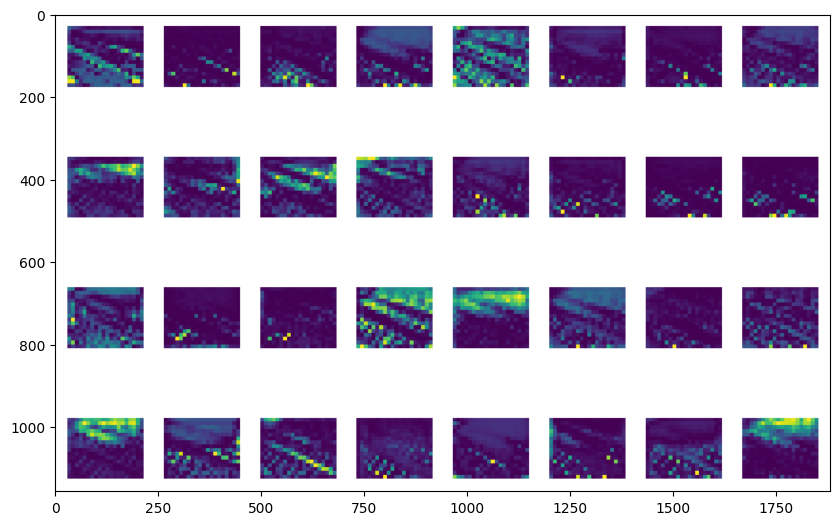

In [75]:
stage_to_show = 21  #maximo 21
for i in stages_images_v8:
  name = i.name
  if 'stage'+str(stage_to_show) in name:
    img = cv2.imread(str(i))
    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

## 2.5 Predicciones de otros escenarios con yolo v8 nano


image 1/7 /content/tests_images/Screenshot_1.png: 256x640 235 pvs, 131.3ms
image 2/7 /content/tests_images/Screenshot_2.png: 224x640 71 pvs, 116.1ms
image 3/7 /content/tests_images/Screenshot_3.png: 256x640 168 pvs, 120.4ms
image 4/7 /content/tests_images/paneles_drone.png: 480x640 138 pvs, 202.8ms
image 5/7 /content/tests_images/paneles_en_techo.png: 480x640 37 pvs, 205.9ms
image 6/7 /content/tests_images/paneles_techo2.png: 416x640 85 pvs, 185.6ms
image 7/7 /content/tests_images/termo_panels.png: 576x640 300 pvs, 230.8ms
Speed: 3.8ms preprocess, 170.4ms inference, 1.9ms postprocess per image at shape (1, 3, 576, 640)


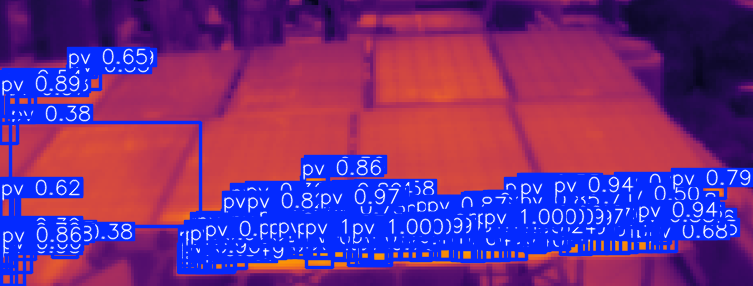

In [76]:
preds_v8_otherImag = model_v8('/content/tests_images',visualize=False)
preds_v8_otherImag[0].show()

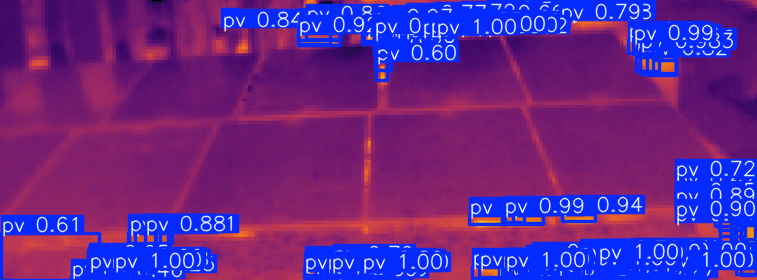

In [77]:
preds_v8_otherImag[2].show()

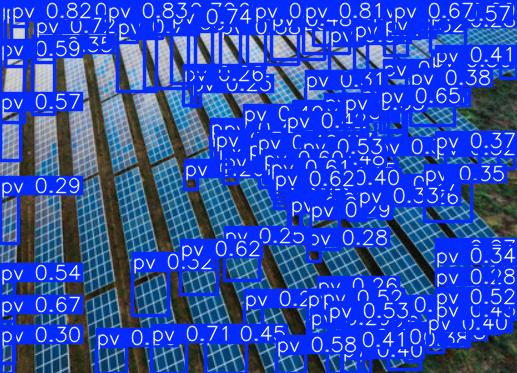

In [78]:
preds_v8_otherImag[3].show()

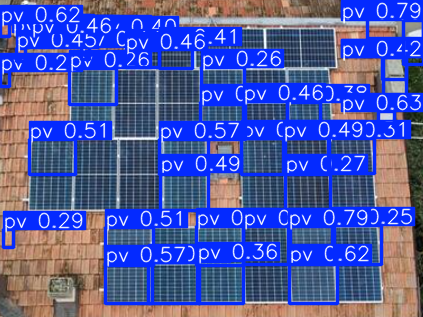

In [79]:
preds_v8_otherImag[4].show()

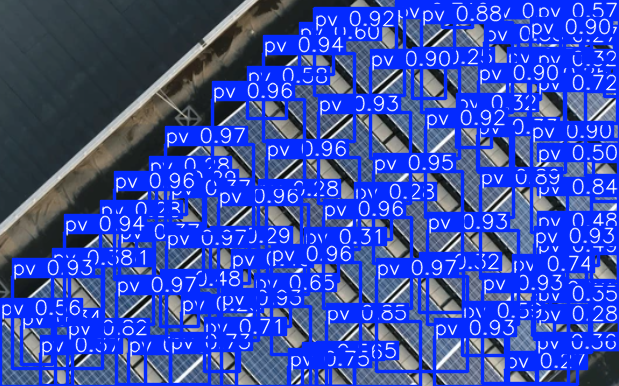

In [80]:
preds_v8_otherImag[5].show()

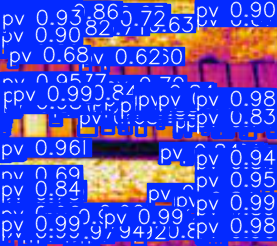

In [81]:
preds_v8_otherImag[6].show()

In [82]:
print(model_v8.model)

DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (act): SiLU(inplace=True)
    )
    (2): C2f(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1))
        (act): SiLU(inplace=True)
      )
      (m): ModuleList(
        (0): Bottleneck(
          (cv1): Conv(
            (conv): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (act): SiLU(inplace=True)
          )
          (cv2): Conv(
            (conv): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (act): SiLU(inplace=True)
          )
        )
      )
    )
    (3): Conv(
      (conv): Conv2d(32

## 2.6 - Afinación de YOLO11 (detección) con el dataset

In [83]:
# 1. Cargar el modelo (nano, el más pequeño)
model_v11 = YOLO("yolo11n.pt")

In [84]:
print(model_v11.model)

DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C3k2(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
   

In [85]:
# Afinar el modelo
results_v11 = model_v11.train(data="/content/datasets/dataset_pv_panels/data.yaml",
                      epochs=10, # Número de iteraciones
                      imgsz=640, # Tamaño de las imágenes (máxima dimensión)
                      plots=True, # Guardar gráficos de entrenamiento
                      )

Ultralytics 8.3.234 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/dataset_pv_panels/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train6, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0

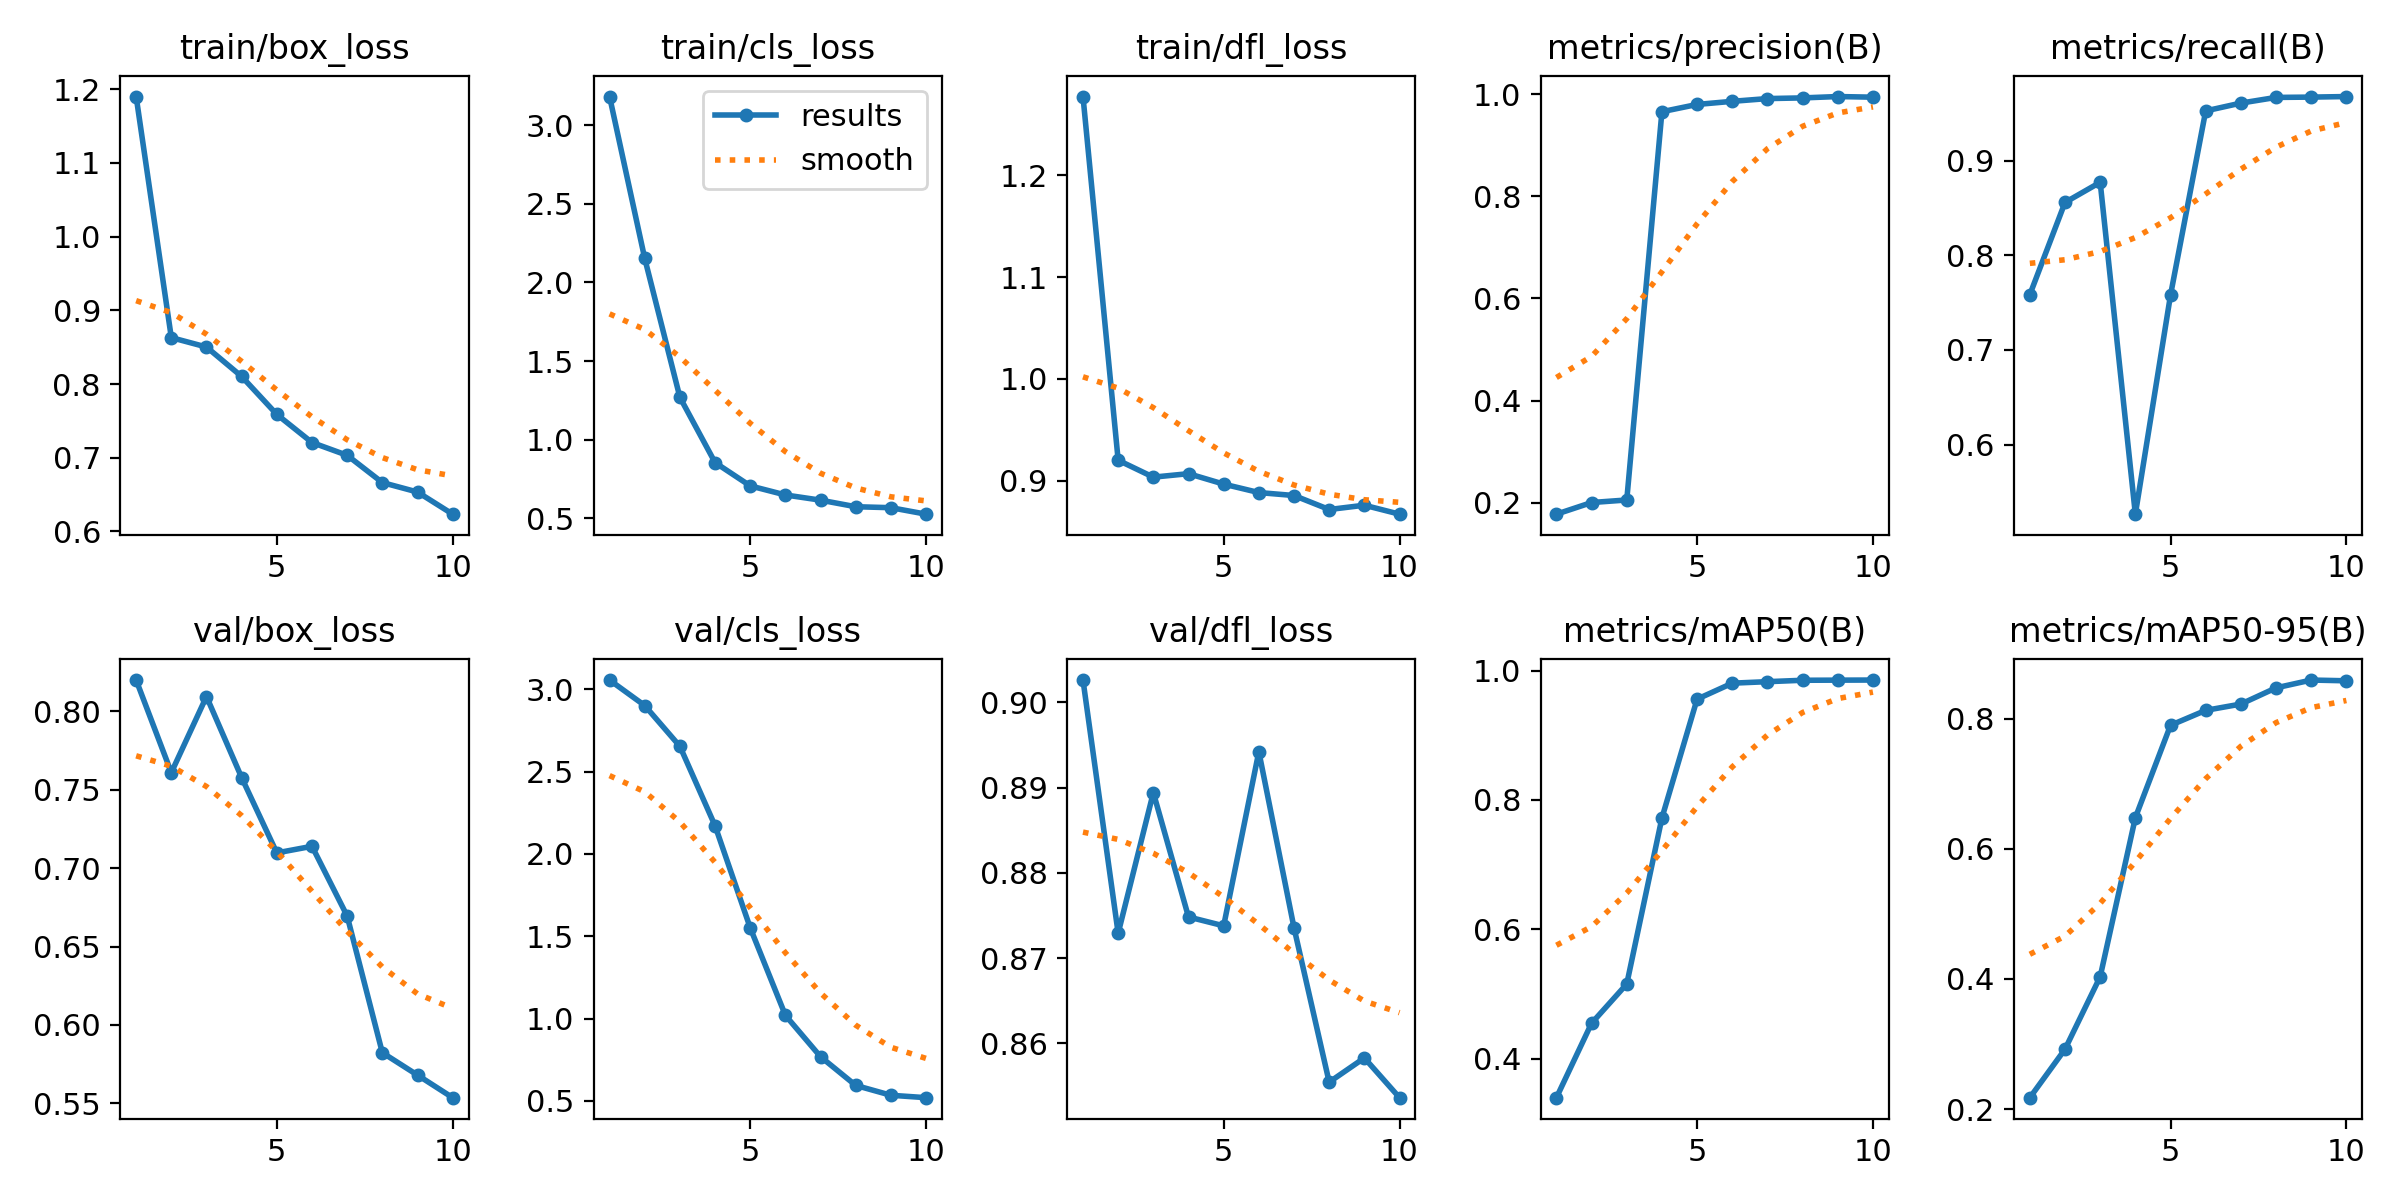

In [86]:
from IPython.display import Image as IPyImage

IPyImage(filename='/content/runs/detect/train2/results.png', width=800)

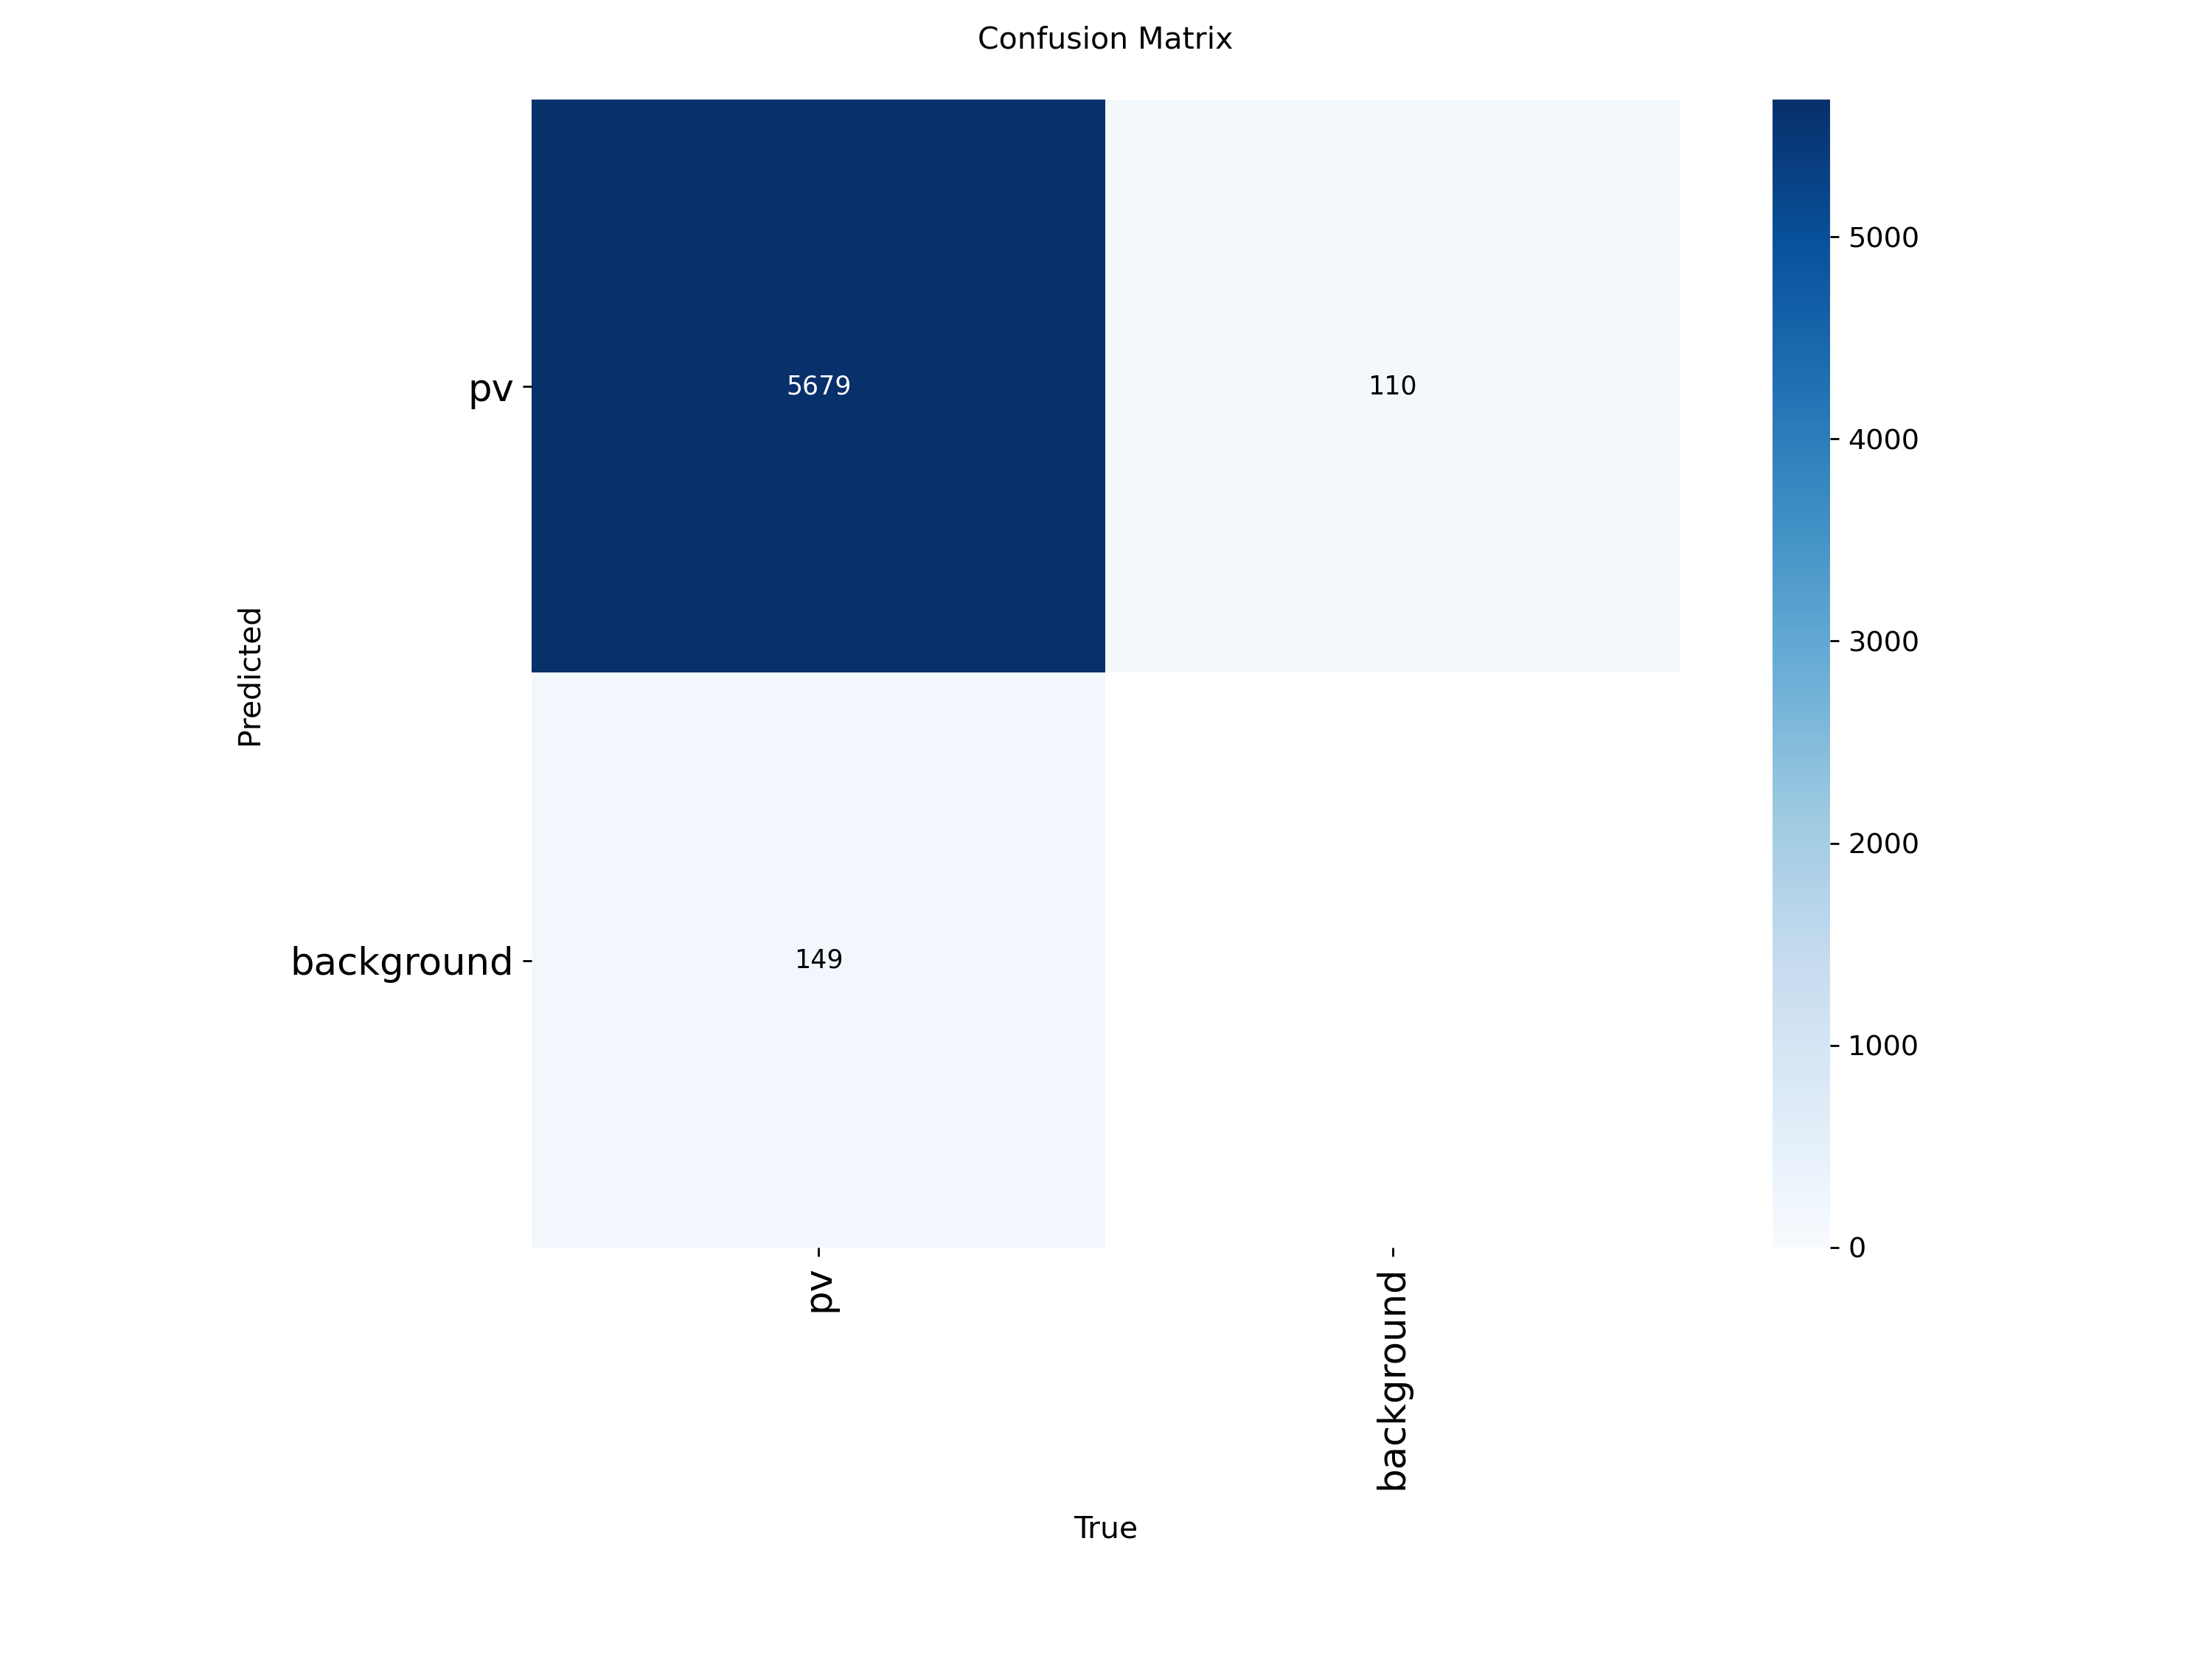

In [87]:
IPyImage(filename='/content/runs/detect/train2/confusion_matrix.png', width=600)

## 2.7 - Generación de predicciones con el modelo afinado yolo v11 nano

In [88]:
# Mostrar predicciones
model_v11 = YOLO('/content/runs/detect/train2/weights/best.pt')
preds_v11 = model_v11('/content/datasets/dataset_pv_panels/images/test')


image 1/35 /content/datasets/dataset_pv_panels/images/test/DJI_20230213153545_0028_T_JPG.rf.2e6811dc7efbb66d491177c8ef91ab9e.jpg: 512x640 13 pvs, 253.2ms
image 2/35 /content/datasets/dataset_pv_panels/images/test/DJI_20230213153619_0029_T_JPG.rf.6655c7256ae6698edfdbe61bff6546e9.jpg: 512x640 64 pvs, 197.0ms
image 3/35 /content/datasets/dataset_pv_panels/images/test/DJI_20230213153842_0062_T_JPG.rf.541b8e07ff96d82b22f1bb8449dc71b4.jpg: 512x640 78 pvs, 202.7ms
image 4/35 /content/datasets/dataset_pv_panels/images/test/DJI_20230213154049_0091_T_JPG.rf.8fd858ff6a748dd9d1773c068a5e3ec4.jpg: 512x640 87 pvs, 209.6ms
image 5/35 /content/datasets/dataset_pv_panels/images/test/DJI_20230213154113_0095_T_JPG.rf.0912d83cce816b165043342ba1fba119.jpg: 512x640 109 pvs, 248.3ms
image 6/35 /content/datasets/dataset_pv_panels/images/test/DJI_20230213154227_0113_T_JPG.rf.70c2736befc0486960d77cfb7346522f.jpg: 512x640 88 pvs, 232.8ms
image 7/35 /content/datasets/dataset_pv_panels/images/test/DJI_20230213154

In [89]:
metrics = model_v11.val(split='test')

print("\nMétricas de rendimiento en el conjunto de prueba:")
print(f"  mAP50: {metrics.results_dict['metrics/mAP50(B)']:.3f}")
print(f"  mAP50-95: {metrics.results_dict['metrics/mAP50-95(B)']:.3f}")
print(f"  Precision: {metrics.results_dict['metrics/precision(B)']:.3f}")
print(f"  Recall: {metrics.results_dict['metrics/recall(B)']:.3f}")

Ultralytics 8.3.234 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 595.5±315.7 MB/s, size: 41.8 KB)
val: Scanning /content/datasets/dataset_pv_panels/labels/test.cache... 35 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 35/35 22.8Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 4.0s/it 12.0s
                   all         35       2363      0.976      0.963      0.992      0.847
Speed: 2.7ms preprocess, 278.6ms inference, 0.0ms loss, 41.0ms postprocess per image
Results saved to /content/runs/detect/val5

Métricas de rendimiento en el conjunto de prueba:
  mAP50: 0.992
  mAP50-95: 0.847
  Precision: 0.976
  Recall: 0.963


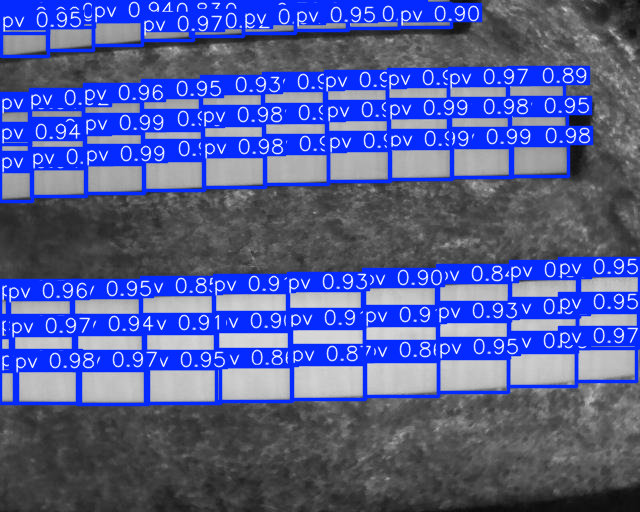

In [90]:
preds_v11[2].show()

Selected random test image: DJI_20230213164146_0073_T_JPG.rf.06a0a8b8df6af8306212653642f20492.jpg
Image loaded with shape: (512, 640, 3)
Found 186 ground truth annotations.

image 1/1 /content/datasets/dataset_pv_panels/images/test/DJI_20230213164146_0073_T_JPG.rf.06a0a8b8df6af8306212653642f20492.jpg: 512x640 183 pvs, 252.2ms
Speed: 5.1ms preprocess, 252.2ms inference, 3.7ms postprocess per image at shape (1, 3, 512, 640)
Model predictions generated.


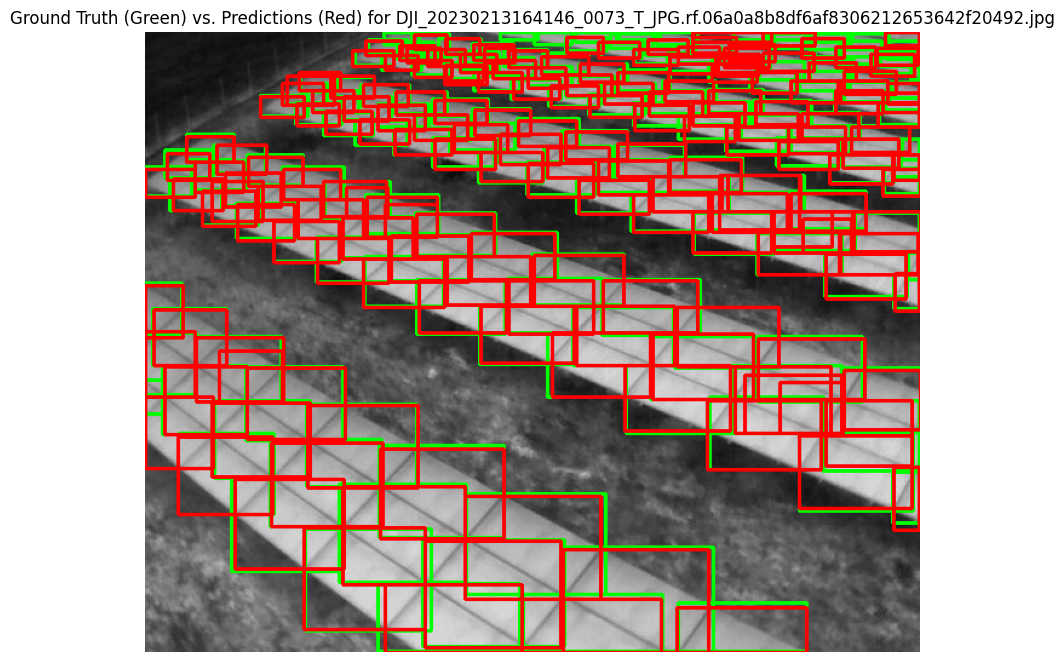

Ground truth vs. predicted bounding box visualization complete for the selected image.


In [91]:
# 1. Define base paths for the dataset's test images and labels
images_test_path = path_pv_dataset / "images" / "test"
labels_test_path = path_pv_dataset / "labels" / "test"

# 2. Get a list of all image file paths within the test directory.
all_test_image_paths = list(images_test_path.iterdir())

# Ensure there are images to process
if not all_test_image_paths:
    print(f"No images found in {images_test_path}")
else:
    # 3. Randomly select one image path from this list for visualization
    selected_image_path = random.choice(all_test_image_paths)
    print(f"Selected random test image: {selected_image_path.name}")

    # 4. Load the selected image using cv2.imread()
    img = cv2.imread(str(selected_image_path))
    if img is None:
        print(f"Error: Could not load image {selected_image_path}")
    else:
        h, w, _ = img.shape
        print(f"Image loaded with shape: {img.shape}")

        # 5. Prepare to load ground truth annotations:
        # Construct the full path to the corresponding YOLO label .txt file
        label_filename = selected_image_path.stem + ".txt"
        ground_truth_label_path = labels_test_path / label_filename

        ground_truth_boxes = [] # Initialize an empty list to store ground truth bounding boxes.

        if ground_truth_label_path.exists():
            with open(ground_truth_label_path, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if len(parts) == 5:
                        class_id = int(parts[0])
                        x_center_norm, y_center_norm, width_norm, height_norm = map(float, parts[1:])

                        # Convert normalized YOLO coordinates to absolute pixel coordinates (x1, y1, x2, y2)
                        x_center_px = int(x_center_norm * w)
                        y_center_px = int(y_center_norm * h)
                        box_width_px = int(width_norm * w)
                        box_height_px = int(height_norm * h)

                        x1 = int(x_center_px - box_width_px / 2)
                        y1 = int(y_center_px - box_height_px / 2)
                        x2 = int(x_center_px + box_width_px / 2)
                        y2 = int(y_center_px + box_height_px / 2)

                        ground_truth_boxes.append((x1, y1, x2, y2))
            print(f"Found {len(ground_truth_boxes)} ground truth annotations.")
        else:
            print(f"No ground truth label file found for {selected_image_path.name} at {ground_truth_label_path}")

        # 6. Create a copy of the loaded image to draw on.
        display_img = img.copy()

        # 7. On this copied image, draw each ground truth bounding box as a green rectangle using cv2.rectangle().
        for (x1, y1, x2, y2) in ground_truth_boxes:
            cv2.rectangle(display_img, (x1, y1), (x2, y2), (0, 255, 0), 2) # Green color, thickness 2

        # 8. Run the already loaded model on the selected image path to get predictions.
        yolo_results = model_v11(str(selected_image_path))
        print("Model predictions generated.")

        # 9. Iterate through the model's prediction results for the image:
        for result in yolo_results:
            for box in result.boxes:
                # Extract bounding box coordinates (x1, y1, x2, y2)
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                confidence = box.conf[0] # Optional: confidence score

                # Draw each predicted bounding box as a red rectangle using cv2.rectangle() on the same copied image.
                cv2.rectangle(display_img, (x1, y1), (x2, y2), (0, 0, 255), 2) # Red color, thickness 2

        # 10. Convert the final image (with both green and red bounding boxes) from BGR to RGB format
        display_img_rgb = cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB)

        # 11. Display the image using plt.imshow(), add an appropriate title, and use plt.axis('off') and plt.show().
        plt.figure(figsize=(10, 10))
        plt.imshow(display_img_rgb)
        plt.title(f'Ground Truth (Green) vs. Predictions (Red) for {selected_image_path.name}')
        plt.axis('off')
        plt.show()

print("Ground truth vs. predicted bounding box visualization complete for the selected image.")

## 2.8 Mapas de filtros segun la capa yolo11n

In [92]:
images_stages_v11 = model_v11.predict(selected_image_path,visualize=True)


Saving /content/runs/detect/predict5/DJI_20230213164146_0073_T_JPG.rf.06a0a8b8df6af8306212653642f20492/stage0_Conv_features.png... (16/16)
Saving /content/runs/detect/predict5/DJI_20230213164146_0073_T_JPG.rf.06a0a8b8df6af8306212653642f20492/stage1_Conv_features.png... (32/32)
Saving /content/runs/detect/predict5/DJI_20230213164146_0073_T_JPG.rf.06a0a8b8df6af8306212653642f20492/stage2_C3k2_features.png... (32/64)
Saving /content/runs/detect/predict5/DJI_20230213164146_0073_T_JPG.rf.06a0a8b8df6af8306212653642f20492/stage3_Conv_features.png... (32/64)
Saving /content/runs/detect/predict5/DJI_20230213164146_0073_T_JPG.rf.06a0a8b8df6af8306212653642f20492/stage4_C3k2_features.png... (32/128)
Saving /content/runs/detect/predict5/DJI_20230213164146_0073_T_JPG.rf.06a0a8b8df6af8306212653642f20492/stage5_Conv_features.png... (32/128)
Saving /content/runs/detect/predict5/DJI_20230213164146_0073_T_JPG.rf.06a0a8b8df6af8306212653642f20492/stage6_C3k2_features.png... (32/128)
Saving /content/runs/de

In [93]:
stages_images_v11 = list(Path(str(images_stages_v11[0].save_dir)).rglob('*.png'))

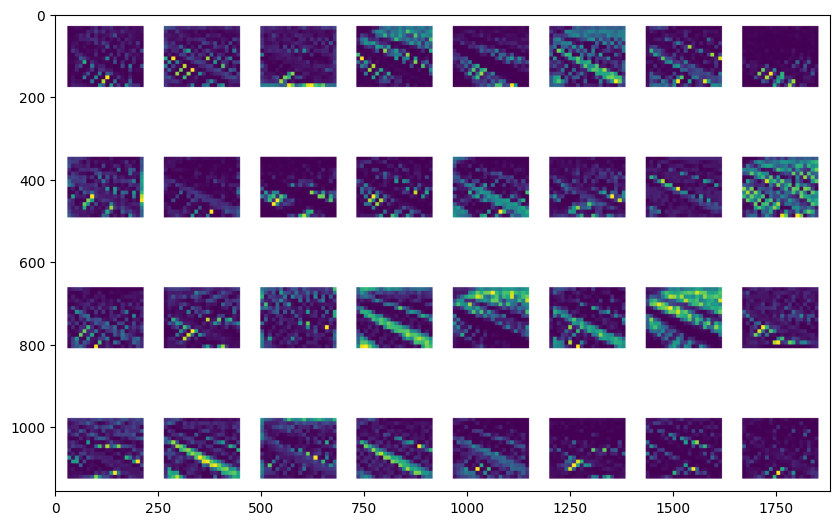

In [94]:
stage_to_show = 21  #maximo 21
for i in stages_images_v11:
  name = i.name
  if 'stage'+str(stage_to_show) in name:
    img = cv2.imread(str(i))
    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

## 2.9 Predicciones de otros escenarios yolov11n


image 1/7 /content/tests_images/Screenshot_1.png: 256x640 (no detections), 232.1ms
image 2/7 /content/tests_images/Screenshot_2.png: 224x640 4 pvs, 192.5ms
image 3/7 /content/tests_images/Screenshot_3.png: 256x640 7 pvs, 174.9ms
image 4/7 /content/tests_images/paneles_drone.png: 480x640 106 pvs, 331.6ms
image 5/7 /content/tests_images/paneles_en_techo.png: 480x640 45 pvs, 278.0ms
image 6/7 /content/tests_images/paneles_techo2.png: 416x640 98 pvs, 272.3ms
image 7/7 /content/tests_images/termo_panels.png: 576x640 10 pvs, 266.4ms
Speed: 5.9ms preprocess, 249.7ms inference, 1.8ms postprocess per image at shape (1, 3, 576, 640)


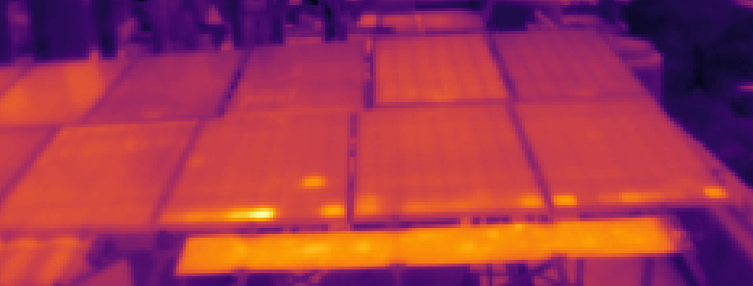

In [95]:
preds_v11_otherImag = model_v11('/content/tests_images',visualize=False)
preds_v11_otherImag[0].show()

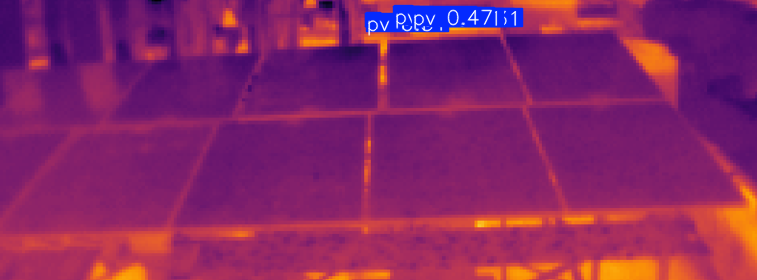

In [96]:
preds_v11_otherImag[2].show()

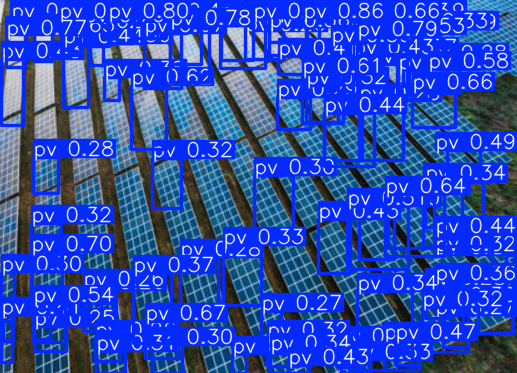

In [97]:
preds_v11_otherImag[3].show()

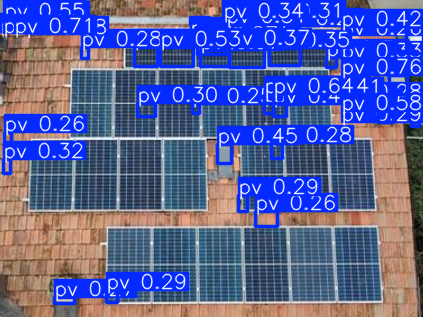

In [98]:
preds_v11_otherImag[4].show()

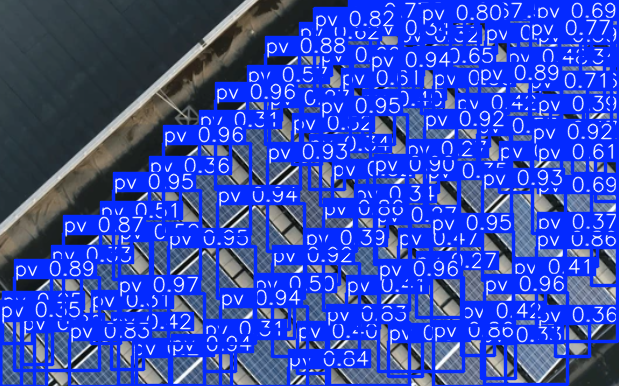

In [99]:
preds_v11_otherImag[5].show()

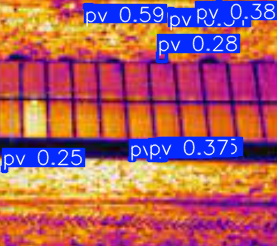

In [100]:
preds_v11_otherImag[6].show()

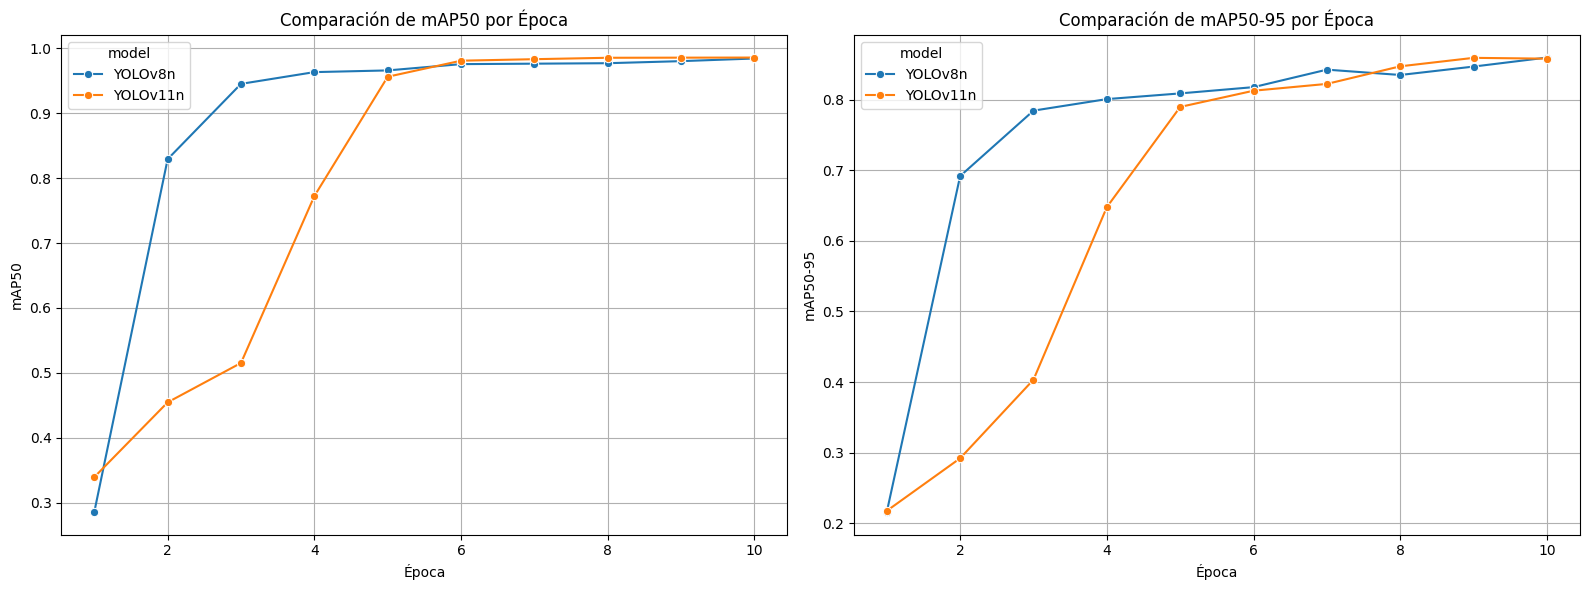

In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load metrics from YOLOv8n results.csv
df_v8_metrics = pd.read_csv('/content/runs/detect/train/results.csv')
df_v8_metrics['model'] = 'YOLOv8n'
df_v8_metrics['epoch'] = range(1, len(df_v8_metrics) + 1)

# Load metrics from YOLOv11n results.csv
df_v11_metrics = pd.read_csv('/content/runs/detect/train2/results.csv')
df_v11_metrics['model'] = 'YOLOv11n'
df_v11_metrics['epoch'] = range(1, len(df_v11_metrics) + 1)

# Combine the metrics DataFrames
combined_metrics_df = pd.concat([df_v8_metrics, df_v11_metrics], ignore_index=True)

# Create subplots for comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot mAP50
sns.lineplot(data=combined_metrics_df, x='epoch', y='metrics/mAP50(B)', hue='model', marker='o', ax=axes[0])
axes[0].set_title('Comparación de mAP50 por Época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('mAP50')
axes[0].grid(True)

# Plot mAP50-95
sns.lineplot(data=combined_metrics_df, x='epoch', y='metrics/mAP50-95(B)', hue='model', marker='o', ax=axes[1])
axes[1].set_title('Comparación de mAP50-95 por Época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('mAP50-95')
axes[1].grid(True)

plt.tight_layout()
plt.show()

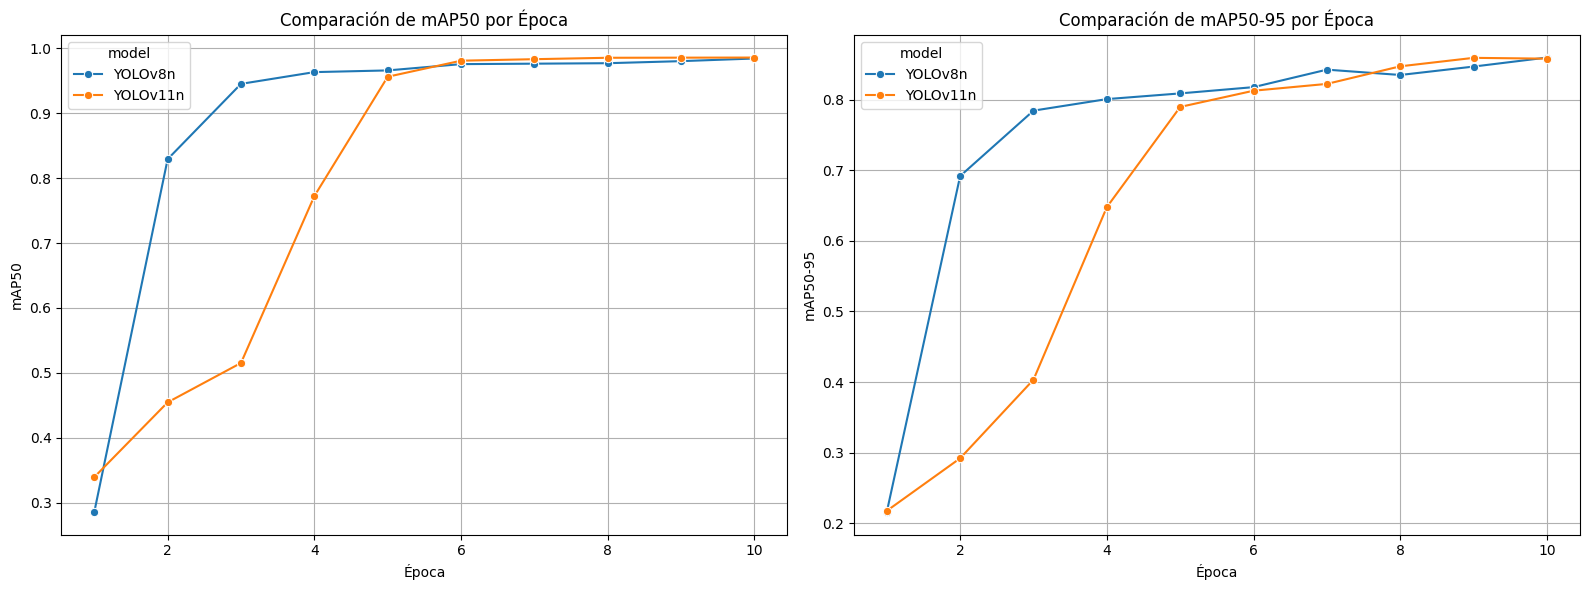

In [102]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load metrics from YOLOv8n results.csv
df_v8_metrics = pd.read_csv('/content/runs/detect/train/results.csv')
df_v8_metrics['model'] = 'YOLOv8n'
df_v8_metrics['epoch'] = range(1, len(df_v8_metrics) + 1)

# Load metrics from YOLOv11n results.csv
df_v11_metrics = pd.read_csv('/content/runs/detect/train2/results.csv')
df_v11_metrics['model'] = 'YOLOv11n'
df_v11_metrics['epoch'] = range(1, len(df_v11_metrics) + 1)

# Combine the metrics DataFrames
combined_metrics_df = pd.concat([df_v8_metrics, df_v11_metrics], ignore_index=True)

# Create subplots for comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot mAP50
sns.lineplot(data=combined_metrics_df, x='epoch', y='metrics/mAP50(B)', hue='model', marker='o', ax=axes[0])
axes[0].set_title('Comparación de mAP50 por Época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('mAP50')
axes[0].grid(True)

# Plot mAP50-95
sns.lineplot(data=combined_metrics_df, x='epoch', y='metrics/mAP50-95(B)', hue='model', marker='o', ax=axes[1])
axes[1].set_title('Comparación de mAP50-95 por Época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('mAP50-95')
axes[1].grid(True)

plt.tight_layout()
plt.show()